In [24]:
from typing import TypedDict, Literal
class PortfolioState(TypedDict): 
    usd_amount_invested: float
    amount_in_usd: float
    amount_in_inr: float
    amount_in_eur: float
    target_currency: Literal["INR","EUR"]
    exchange_rate_usd_inr: float
    exchange_rate_usd_eur: float

def calculate_investment_returns(portfolio_state: PortfolioState) -> PortfolioState:
    portfolio_state["amount_in_usd"]=portfolio_state["usd_amount_invested"] * 1.12 
    return portfolio_state

def convert_usd_to_inr(portfolio_state: PortfolioState) -> PortfolioState:
    portfolio_state["amount_in_inr"] = portfolio_state["amount_in_usd"] * portfolio_state["exchange_rate_usd_inr"]
    return portfolio_state

def convert_usd_to_eur(portfolio_state: PortfolioState) -> PortfolioState:
    portfolio_state["amount_in_eur"] = portfolio_state["amount_in_usd"] * portfolio_state["exchange_rate_usd_eur"]
    return portfolio_state

def choose_currency(portfolio_state: PortfolioState) -> str:
    return portfolio_state["target_currency"]


In [25]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortfolioState)

builder.add_node("calculate_investment_node", calculate_investment_returns)

builder.add_node("convert_usd_to_inr_node", convert_usd_to_inr)

builder.add_node("convert_usd_to_eur_node", convert_usd_to_eur)

builder.add_edge(START, "calculate_investment_node")

builder.add_conditional_edges(
    "calculate_investment_node",  
    choose_currency,
    {
        "INR": "convert_usd_to_inr_node",
        "EUR": "convert_usd_to_eur_node"
    }
)


builder.add_edge(["convert_usd_to_inr_node","convert_usd_to_eur_node"], END)

graph = builder.compile()

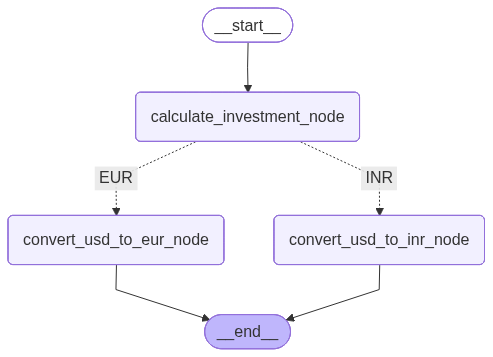

In [26]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
graph.invoke({
    "usd_amount_invested": 25000,
    "exchange_rate_usd_inr": 94.0,
    "exchange_rate_usd_eur": 0.9,
    "target_currency": "EUR"
})

{'usd_amount_invested': 25000,
 'amount_in_usd': 28000.000000000004,
 'amount_in_eur': 25200.000000000004,
 'target_currency': 'EUR',
 'exchange_rate_usd_inr': 94.0,
 'exchange_rate_usd_eur': 0.9}